# Problem Statement

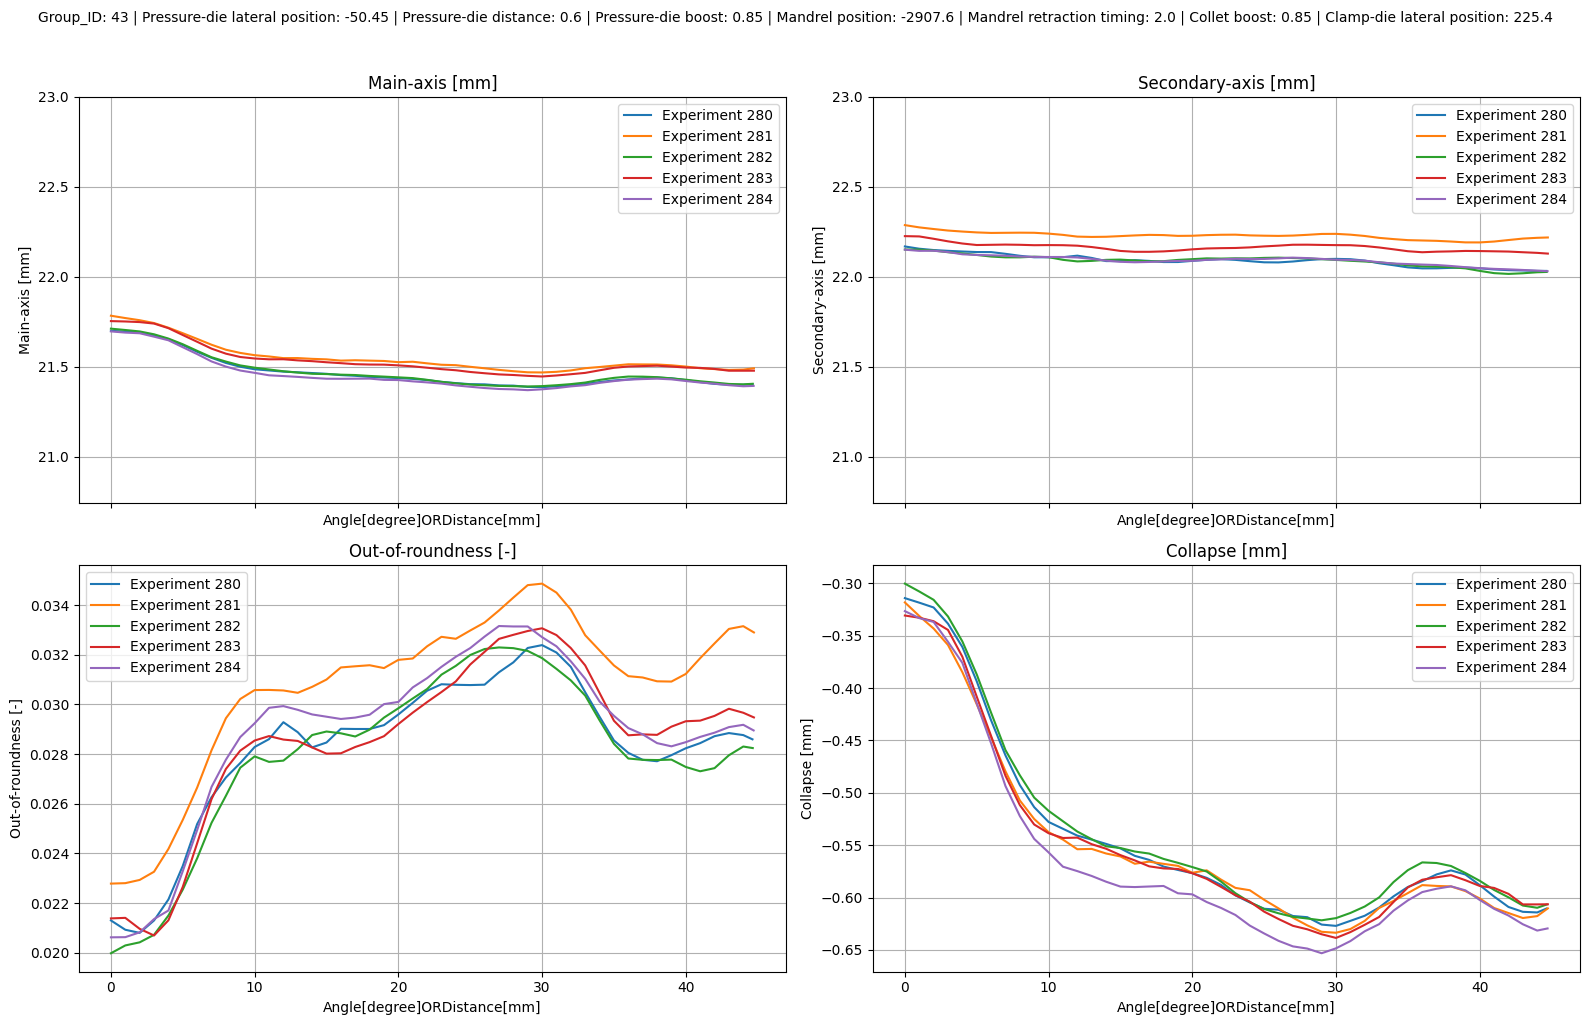

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

file_path = "/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/raw/unique_bending_setups.csv"
bending_df = pd.read_csv(file_path)

group_id = 43

row = bending_df[bending_df["Group_ID"] == group_id].iloc[0]

experiment_ids = ast.literal_eval(row["Experiment_Number"])

geometry_path = "/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/processed/geometry.csv"
geometry_df = pd.read_csv(geometry_path)

selected_geometry_df = geometry_df[
    geometry_df["Experiment_ID"].isin(experiment_ids)
]

setup_columns = [
    "Group_ID",
    "Pressure-die lateral position",
    "Pressure-die distance",
    "Pressure-die boost",
    "Mandrel position",
    "Mandrel retraction timing",
    "Collet boost",
    "Clamp-die lateral position",
]

setup_text = " | ".join([f"{col}: {row[col]}" for col in setup_columns])

plot_columns = [
    "Main-axis [mm]",
    "Secondary-axis [mm]",
    "Out-of-roundness [-]",
    "Collapse [mm]",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for ax, y_col in zip(axes, plot_columns):
    for experiment_id in experiment_ids:
        exp_df = selected_geometry_df[
            selected_geometry_df["Experiment_ID"] == experiment_id
        ]

        ax.plot(
            exp_df["Angle[degree]ORDistance[mm]"],
            exp_df[y_col],
            linestyle="-",
            label=f"Experiment {experiment_id}"
        )

    ax.set_title(y_col)
    ax.set_xlabel("Angle[degree]ORDistance[mm]")
    ax.set_ylabel(y_col)
    ax.grid(True)
    ax.legend()

axes[0].set_ylim(20.74, 23)
axes[1].set_ylim(20.74, 23)

fig.suptitle(setup_text, fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
geometry_df[["Secondary-axis [mm]", "Main-axis [mm]"]].agg(["min", "max"])

,Secondary-axis [mm],Main-axis [mm]
min,21.958278,20.749683
max,22.548962,22.837233


# Correlation Matrix


Pearson Correlation Matrix

                      Main-axis [mm]  Secondary-axis [mm]  \
Main-axis [mm]                 1.000               -0.349   
Secondary-axis [mm]           -0.349                1.000   
Out-of-roundness [-]          -0.947                0.632   
Collapse [mm]                  0.991               -0.413   

                      Out-of-roundness [-]  Collapse [mm]  
Main-axis [mm]                      -0.947          0.991  
Secondary-axis [mm]                  0.632         -0.413  
Out-of-roundness [-]                 1.000         -0.961  
Collapse [mm]                       -0.961          1.000  


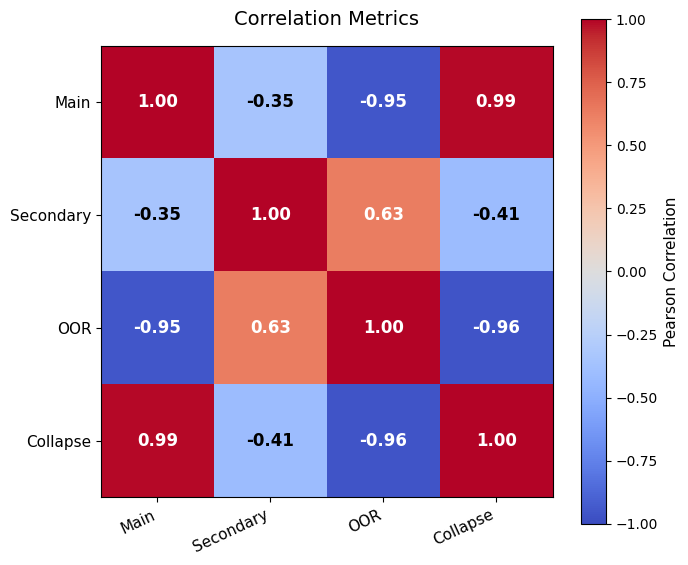

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load geometry data
# -----------------------------
geometry_path = "/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/processed/geometry.csv"
geometry_df = pd.read_csv(geometry_path)

# -----------------------------
# Quality metrics
# -----------------------------
quality_columns = [
    "Main-axis [mm]",
    "Secondary-axis [mm]",
    "Out-of-roundness [-]",
    "Collapse [mm]",
]

# -----------------------------
# Pearson correlation matrix
# -----------------------------
corr = geometry_df[quality_columns].corr(method="pearson")

print("\nPearson Correlation Matrix\n")
print(corr.round(3))

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# ticks
ax.set_xticks(np.arange(len(quality_columns)))
ax.set_yticks(np.arange(len(quality_columns)))

ax.set_xticklabels(
    ["Main", "Secondary", "OOR", "Collapse"],
    fontsize=11
)
ax.set_yticklabels(
    ["Main", "Secondary", "OOR", "Collapse"],
    fontsize=11
)

plt.setp(ax.get_xticklabels(), rotation=25, ha="right")

# values inside cells
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.6 else "black",
            fontsize=12,
            fontweight="bold"
        )

cbar = plt.colorbar(im)
cbar.set_label("Pearson Correlation", fontsize=11)

ax.set_title(
    "Correlation Metrics",
    fontsize=14,
    pad=15,
)

plt.tight_layout()
plt.show()

# Bending Setup Exploration

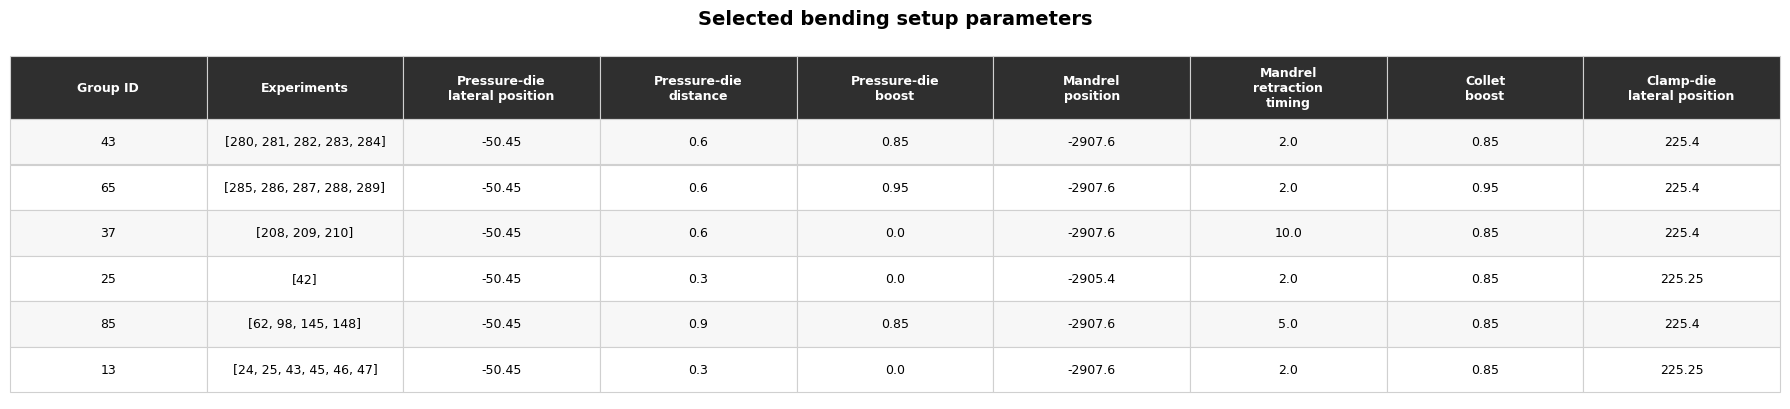

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


path = Path(
    "/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/raw/unique_bending_setups.csv"
)

group_ids = [43, 65, 37, 25, 85, 13]

columns = [
    "Group_ID",
    "Experiment_Number",
    "Pressure-die lateral position",
    "Pressure-die distance",
    "Pressure-die boost",
    "Mandrel position",
    "Mandrel retraction timing",
    "Collet boost",
    "Clamp-die lateral position",
]

display_columns = [
    "Group ID",
    "Experiments",
    "Pressure-die\nlateral position",
    "Pressure-die\ndistance",
    "Pressure-die\nboost",
    "Mandrel\nposition",
    "Mandrel\nretraction\ntiming",
    "Collet\nboost",
    "Clamp-die\nlateral position",
]

df = pd.read_csv(path)

selected_rows = df[
    pd.to_numeric(df["Group_ID"], errors="coerce").isin(group_ids)
].copy()

selected_rows = selected_rows.sort_values(
    "Group_ID",
    key=lambda series: series.map(
        {group_id: index for index, group_id in enumerate(group_ids)}
    ),
)

result = selected_rows[columns].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(18, 4.2))
ax.axis("off")

table = ax.table(
    cellText=result.astype(str).values,
    colLabels=display_columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D0D0")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_facecolor("#2F2F2F")
        cell.set_text_props(color="white", weight="bold", fontsize=9)
        cell.set_height(0.18)
    else:
        cell.set_facecolor("#F7F7F7" if row % 2 else "#FFFFFF")
        cell.set_height(0.13)

ax.set_title(
    "Selected bending setup parameters",
    fontsize=14,
    weight="bold",
    pad=18,
)

plt.tight_layout()
plt.show()